In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Load dataset
news_df = pd.read_csv("../data/raw/raw_analyst_ratings.csv")

In [5]:
# Show first 5 rows
news_df.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [6]:
# Dataset information
news_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype
---  ------      --------------    -----
 0   Unnamed: 0  1407328 non-null  int64
 1   headline    1407328 non-null  str  
 2   url         1407328 non-null  str  
 3   publisher   1407328 non-null  str  
 4   date        1407328 non-null  str  
 5   stock       1407328 non-null  str  
dtypes: int64(1), str(5)
memory usage: 64.4 MB


In [ ]:
# Check missing values
news_df.isnull().sum()

In [7]:
# Dataset shape
print("Rows:", news_df.shape[0])
print("Columns:", news_df.shape[1])

Rows: 1407328
Columns: 6


In [8]:
# Create headline length column
news_df["headline_length"] = news_df["headline"].str.len()

# Statistics
news_df["headline_length"].describe()

count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64

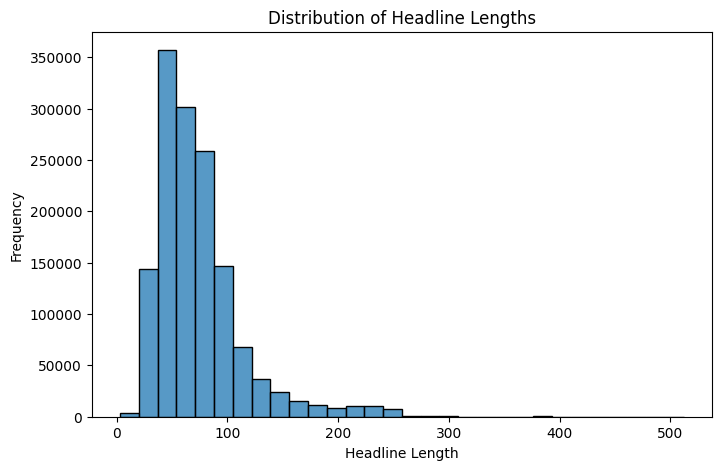

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(news_df["headline_length"], bins=30)

plt.title("Distribution of Headline Lengths")
plt.xlabel("Headline Length")
plt.ylabel("Frequency")

plt.show()

In [10]:
# Top 10 publishers
top_publishers = news_df["publisher"].value_counts().head(10)

top_publishers

publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64

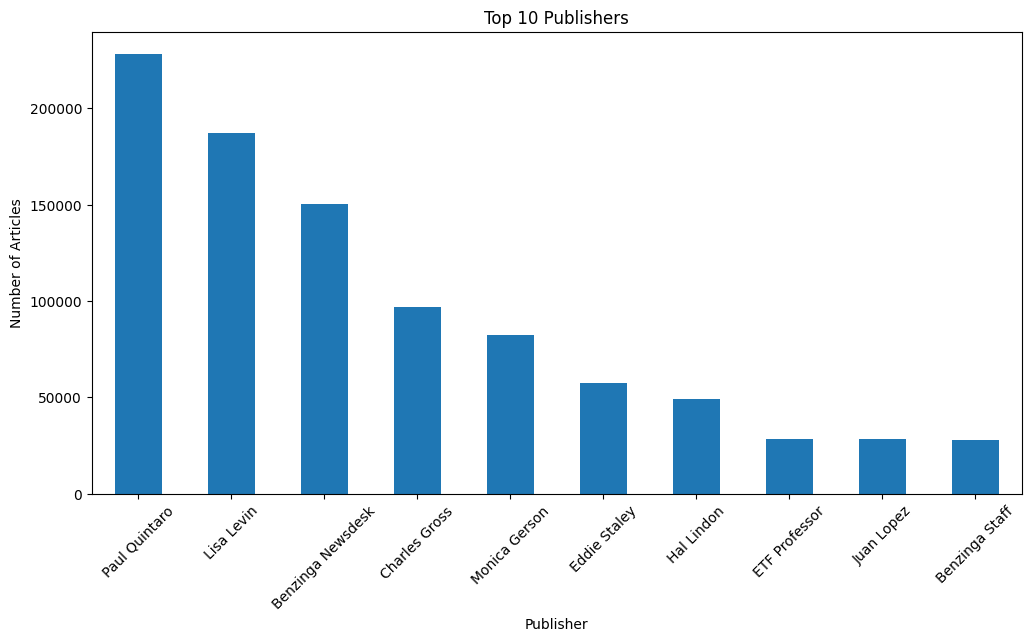

In [11]:
plt.figure(figsize=(12,6))

top_publishers.plot(kind="bar")

plt.title("Top 10 Publishers")
plt.xlabel("Publisher")
plt.ylabel("Number of Articles")

plt.xticks(rotation=45)

plt.show()

### Insight
Paul Qunitaro-related publishers contribute the largest portion of financial news articles in the dataset, indicating that the dataset is heavily influenced by a few dominant financial news providers.

In [12]:
# Count articles per stock
stock_counts = news_df["stock"].value_counts().head(10)

stock_counts

stock
MRK     3333
MS      3238
NVDA    3146
MU      3142
QQQ     3106
NFLX    3028
M       3025
EBAY    3018
GILD    2968
VZ      2966
Name: count, dtype: int64

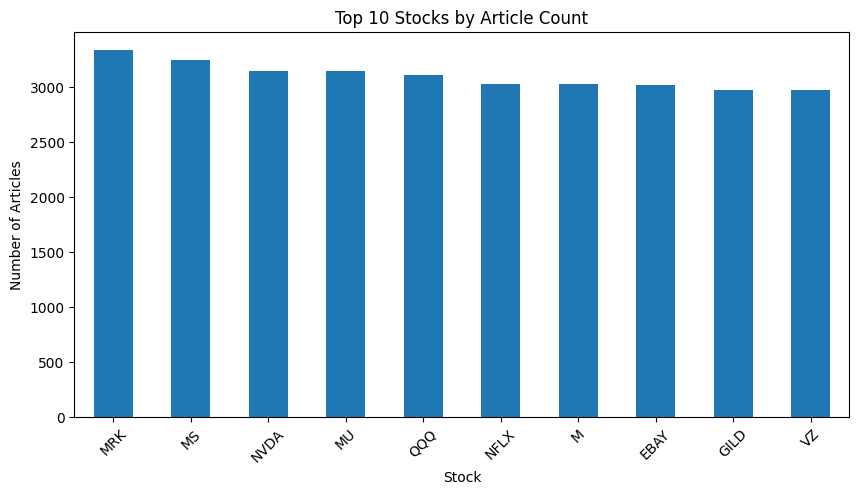

In [13]:
plt.figure(figsize=(10,5))

stock_counts.plot(kind="bar")

plt.title("Top 10 Stocks by Article Count")
plt.xlabel("Stock")
plt.ylabel("Number of Articles")

plt.xticks(rotation=45)

plt.show()

MRK stocks receive significantly more media attention than others, suggesting that large-cap or highly volatile companies attract greater financial news coverage.

In [21]:
# Convert mixed date formats safely
news_df["date"] = pd.to_datetime(
    news_df["date"],
    format="mixed",
    utc=True
)

# Preview
news_df["date"].head()

0   2020-06-05 14:30:54+00:00
1   2020-06-03 14:45:20+00:00
2   2020-05-26 08:30:07+00:00
3   2020-05-22 16:45:06+00:00
4   2020-05-22 15:38:59+00:00
Name: date, dtype: datetime64[us, UTC]

In [22]:
# Count articles per day
daily_news = news_df.groupby(news_df["date"].dt.date).size()

daily_news.head()

date
2009-02-14    1
2009-04-27    2
2009-04-29    1
2009-05-22    1
2009-05-27    6
dtype: int64

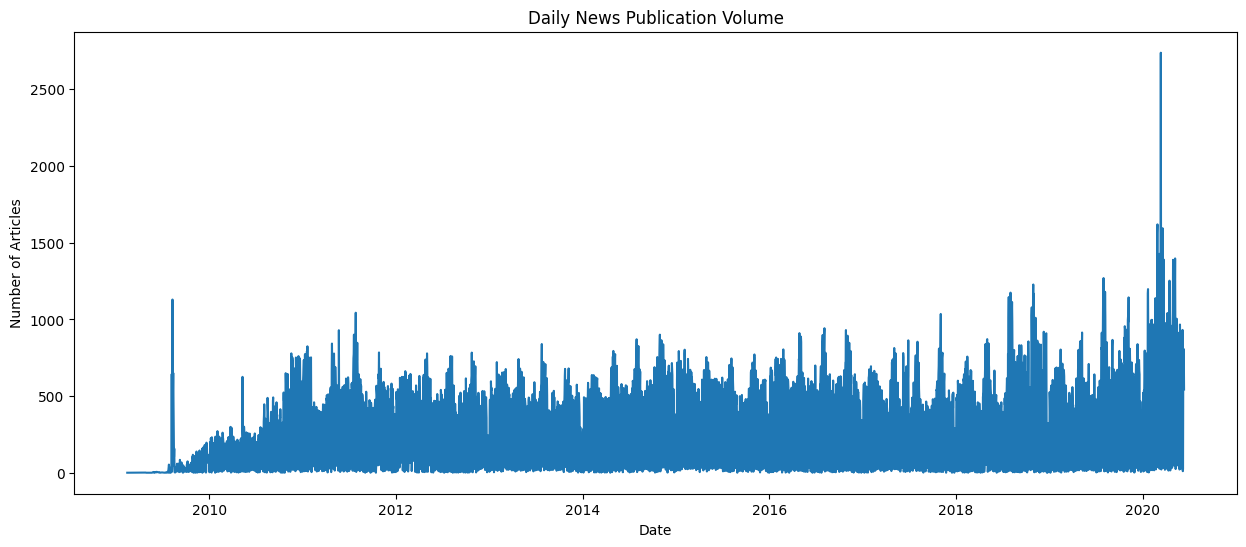

In [23]:
plt.figure(figsize=(15,6))

daily_news.plot()

plt.title("Daily News Publication Volume")
plt.xlabel("Date")
plt.ylabel("Number of Articles")

plt.show()

In [25]:
from sklearn.feature_extraction.text import CountVectorizer

In [26]:
# Create vectorizer
vectorizer = CountVectorizer(
    stop_words='english',
    max_features=20
)

# Fit headlines
X = vectorizer.fit_transform(news_df["headline"])

# Get word counts
word_counts = X.sum(axis=0)

# Convert to dataframe
words_freq = pd.DataFrame({
    "word": vectorizer.get_feature_names_out(),
    "count": word_counts.A1
})

# Sort descending
words_freq = words_freq.sort_values(by="count", ascending=False)

words_freq


,word,count
18,vs,162099
15,stocks,161776
6,est,140604
5,eps,128897
7,market,120558
14,shares,114313
12,reports,108710
17,update,91723
4,earnings,87399
13,sales,79645


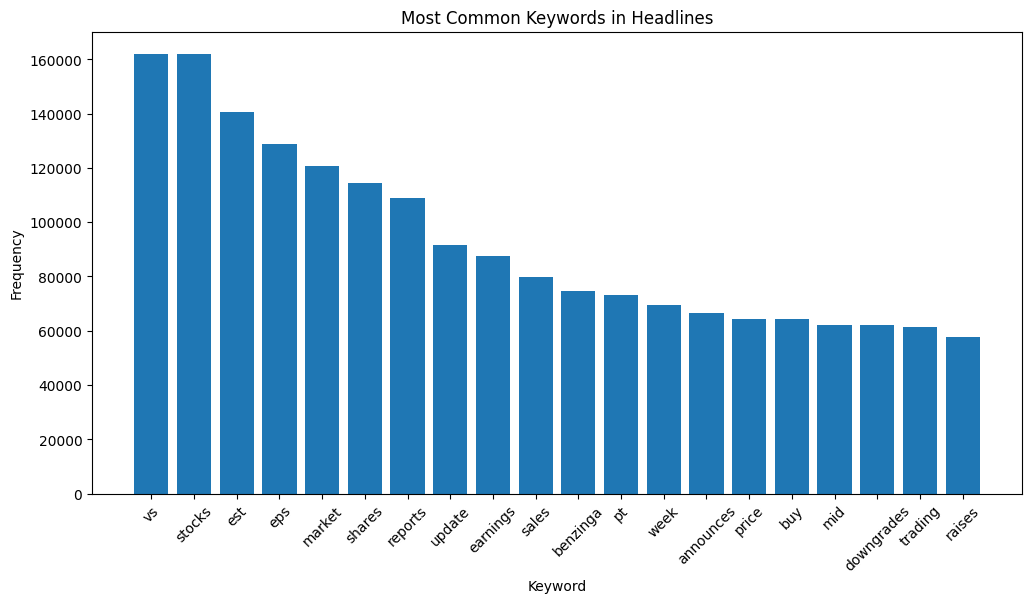

In [27]:
plt.figure(figsize=(12,6))

plt.bar(words_freq["word"], words_freq["count"])

plt.title("Most Common Keywords in Headlines")
plt.xlabel("Keyword")
plt.ylabel("Frequency")

plt.xticks(rotation=45)

plt.show()

### Insight

The most frequently occurring words in the headlines are strongly related to financial performance, analyst recommendations, stock movement, and earnings activity. Terms such as “earnings”, “market”, “price”, “shares”, and “trading” indicate that the dataset primarily focuses on stock analysis and market behavior.